# BGDRegression

In [41]:
class MyBGDRegression:
    def __init__(self):
        self.intercept_ = 0.0
        self.coef_ = []

    def fit(self, x, y, learningRate = 0.001, noEpochs = 1000, batches = 20):
        self.coef_ = [0.0 for _ in range(len(x[0]) + 1)]
        for epoch in range(noEpochs):
            for i in range(0, len(x), batches):
                ycomputed = [self.eval(xi) for xi in x[i:i + batches]]
                crtErrors = [yc - yi for yc, yi in
                             zip(ycomputed, y[i:i + batches])]#prezise si reale
                for j in range(0, len(x[0])):
                    self.coef_[j] = self.coef_[j] - learningRate * sum(
                        [crtError * xi[j] for crtError, xi in zip(crtErrors, x[i:i + batches])])
                self.coef_[len(x[0])] = self.coef_[len(x[0])] - learningRate * sum(crtErrors)

        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]

    def eval(self, xi):
        yi = self.coef_[-1]
        for j in range(len(xi)):
            yi += self.coef_[j] * xi[j]
        return yi

    def predict(self, x):
        yComputed = [self.eval(xi) for xi in x]
        return yComputed

# Logistic Regression

In [42]:
import numpy as np


class MyLogisticRegression1:
    def __init__(self, learning_rate=0.01, num_iterations=100000, verbose=True, thresholds=[0.5]):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.verbose = verbose
        self.theta = None
        self.thresholds = thresholds

    def __sigmoid(self, z):#activare
        return 1 / (1 + np.exp(-z))
    
    #masoara cat de bine se potrivesc probabilitatile prezise cu etichetele reale
    def __binary_cross_entropy_loss(self, h, y): # Binary Cross-Entropy Loss
        return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()
    
    #este bazata pe o marja
    def __hinge_loss(self, h, y, threshold): # Hinge Loss
        y_pred = (h >= threshold).astype(int) * 2 - 1
        return np.maximum(0, 1 - y * y_pred).mean()
    
    #masoara diferenta patratica dintre valorile prezise si cele reale
    def __mean_squared_error(self, h, y, threshold): # Mean Squared Error
        y_pred = (h >= threshold).astype(int)
        return ((y_pred - y) ** 2).mean()

    #modelul de regresie logistica
    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros(n + 1)

        X = np.concatenate((np.ones((m, 1)), X), axis=1)

        for i in range(self.num_iterations):
            z = np.dot(X, self.theta)
            h = self.__sigmoid(z)
            gradient = np.dot(X.T, (h - y)) / m
            self.theta -= self.learning_rate * gradient

            if self.verbose and i % 10000 == 0:
                z = np.dot(X, self.theta)
                h = self.__sigmoid(z)
                # investigarea diferitelor funcții de loss (optional)
                for threshold in self.thresholds:
                    print(f'Loss at iteration {i}: {self.__binary_cross_entropy_loss(h, y)} (Binary Cross-Entropy Loss)')
                    print(f'Loss at iteration {i} with threshold {threshold}: {self.__hinge_loss(h, y, threshold)} (Hinge Loss)')
                    print(f'Loss at iteration {i} with threshold {threshold}: {self.__mean_squared_error(h, y, threshold)} (Mean Squared Error)')
                print()

    def predict(self, X):
        m = X.shape[0]
        X = np.concatenate((np.ones((m, 1)), X), axis=1)
        z = np.dot(X, self.theta)
        return np.round(self.__sigmoid(z))

# Logistic Regression v2

In [43]:
import math

class MyLogisticRegression2:
    def __init__(self, learning_rate=0.01, num_iterations=1000, threshold=0.33):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.threshold = threshold
        self.theta = []

    def sigmoid(self, z):
        return 1 / (1 + math.exp(-z))

#produs scalar
    def dot(self, a, b):
        return sum([x * y for x, y in zip(a, b)])
#termenul de bias
    def add_bias(self, X):
        return [[1.0] + row for row in X]
    def predict_prob(self, X):
        return [self.sigmoid(self.dot(x, self.theta)) for x in X]
#eroare intre valorile reale y si predictiile probabilistice

    def cost_function(self, X, y):
        m = len(y)
        h = self.predict_prob(X)
        epsilon = 1e-5
        cost = 0.0
        for i in range(m):
            cost += -y[i] * math.log(h[i] + epsilon) - (1 - y[i]) * math.log(1 - h[i] + epsilon)
        return cost / m

    def gradient_descent(self, X, y):
        m = len(y)
        n = len(X[0])
        self.theta = [0.0] * n

        for _ in range(self.num_iterations):
            h = self.predict_prob(X)
            gradients = [0.0] * n

            for j in range(n):
                for i in range(m):
                    gradients[j] += (h[i] - y[i]) * X[i][j]
                gradients[j] /= m

            for j in range(n):
                self.theta[j] -= self.learning_rate * gradients[j]

    def fit(self, X, y):
        X = self.add_bias(X)
        self.gradient_descent(X, y)

    def predict(self, X):
        X = self.add_bias(X)
        probs = self.predict_prob(X)
        return [1 if p >= self.threshold else 0 for p in probs]


# SGD Regression    

In [44]:
class MySGDRegression:
    def __init__(self):
        self.intercept_ = 0.0  # interceptul (bias-ul) modelului
        self.coef_ = []  # coeficientii modelului (panta pentru fiecare caracteristica)

    # Functie pentru a antrena modelul folosind Stochastic Gradient Descent
    def fit(self, x, y, learningRate = 0.001, noEpochs = 1000):
        self.coef_ = [0.0 for _ in range(len(x[0]) + 1)]  # initializare coeficienti (inclusiv bias)

        # Itereaza prin epoci
        for epoch in range(noEpochs):
            for i in range(len(x)):  # pentru fiecare exemplu din setul de antrenament
                ycomputed = self.eval(x[i])  # estimeaza iesirea (y) folosind coeficientii curenti
                crtError = ycomputed - y[i]  # calculeaza eroarea pentru exemplul curent

                # Actualizeaza coeficientii folosind eroarea curenta si gradul de invatare
                for j in range(0, len(x[0])):  # actualizare pentru fiecare caracteristica
                    self.coef_[j] = self.coef_[j] - learningRate * crtError * x[i][j]

                # Actualizare pentru intercept (bias)
                self.coef_[len(x[0])] = self.coef_[len(x[0])] - learningRate * crtError * 1

        # Se salveaza interceptul (ultima valoare din coeficienti)
        self.intercept_ = self.coef_[-1]
        self.coef_ = self.coef_[:-1]  # Elimina ultimul coeficient, care este interceptul

    # Functie pentru a evalua iesirea pentru un set de date (estimarea modelului)
    def eval(self, xi):
        yi = self.coef_[-1]  # incepe cu interceptul (bias)
        for j in range(len(xi)):  # aduna contributia fiecarui coeficient pentru fiecare caracteristica
            yi += self.coef_[j] * xi[j]
        return yi

    # Functie pentru a face predictii pe un set de date
    def predict(self, x):
        yComputed = [self.eval(xi) for xi in x]  # estimeaza iesirile pentru fiecare exemplu
        return yComputed


# 1. univariate gradient descent

In [45]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Functie pentru a incarca datele din fisierul CSV
def loadData(fileName, inputVariabName, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable = dataNames.index(inputVariabName)
    inputs = [float(data[i][selectedVariable]) for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs

# Functie pentru a desena histograma pentru o variabila
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

# Functie pentru a desena datele si modelele
def plotData(x1, y1, x2 = None, y2 = None, x3 = None, y3 = None, title = None):
    plt.plot(x1, y1, 'ro', label = 'train data')
    if (x2):
        plt.plot(x2, y2, 'b-', label = 'learnt model')
    if (x3):
        plt.plot(x3, y3, 'g^', label = 'test data')
    plt.title(title)
    plt.legend()
    plt.show()

# Functie pentru a aplica gradient descent pe univariata
def univariate_gradient_descent(model):
    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

    # Incarca datele
    inputs, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Happiness.Score')

    # Deseneaza histogramele
    plotDataHistogram(inputs, 'capita GDP')
    plotDataHistogram(outputs, 'Happiness score')

    # Verifica linearitatea
    plotData(inputs, outputs, [], [], [], [], 'capita vs. hapiness')

    # Impartirea datelor in training (80%) si testare (20%)
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    validationSample = [i for i in indexes if not i in trainSample]
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    validationInputs = [inputs[i] for i in validationSample]
    validationOutputs = [outputs[i] for i in validationSample]

    # Deseneaza datele de antrenament si testare
    plotData(trainInputs, trainOutputs, [], [], validationInputs, validationOutputs, "train and test data")

    # Pasul de antrenament
    xx = [[el] for el in trainInputs]
    if (model == "stocastic"):
        regressor = MySGDRegression()
    else:
        regressor = MyBGDRegression()
    regressor.fit(xx, trainOutputs)
    w0, w1 = regressor.intercept_, regressor.coef_[0]
    print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x')

    # Deseneaza modelul
    noOfPoints = 1000
    xref = []
    val = min(trainInputs)
    step = (max(trainInputs) - min(trainInputs)) / noOfPoints
    for i in range(1, noOfPoints):
        xref.append(val)
        val += step
    yref = [w0 + w1 * el for el in xref]
    plotData(trainInputs, trainOutputs, xref, yref, [], [], title="train data and model")

    # Realizeaza predictii pentru datele de testare
    computedValidationOutputs = regressor.predict([[x] for x in validationInputs])
    plotData([], [], validationInputs, computedValidationOutputs, validationInputs, validationOutputs,
             "predictions vs real test data")

    # Calculeaza eroarea dintre predictii si valorile reale
    error = 0.0
    for t1, t2 in zip(computedValidationOutputs, validationOutputs):
        error += (t1 - t2) ** 2
    error = error / len(validationOutputs)
    print("prediction error (manual): ", error)

    # Calculeaza eroarea folosind functia predefinita
    error = mean_squared_error(validationOutputs, computedValidationOutputs)
    print("prediction error (tool): ", error)


# 1. bivariate gradient descent

In [46]:
import csv
import os
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from math import sqrt


# Functie pentru a afisa date in 3D
def plot3Ddata(x1Train, x2Train, yTrain, x1Model = None, x2Model = None, yModel = None, x1Test = None, x2Test = None, yTest = None, title = None):
    # Functie pentru a elimina valorile negative din date
    def remove_negative_values(feature1, feature2, outputs):
        new_feature1 = []
        new_feature2 = []
        new_outputs = []
        for f1, f2, out in zip(feature1, feature2, outputs):
            if f1 >= 0 and f2 >= 0 and out >= 0:
                new_feature1.append(f1)
                new_feature2.append(f2)
                new_outputs.append(out)
        return new_feature1, new_feature2, new_outputs

    # Elimina valorile negative din datele de antrenament si test (daca sunt furnizate)
    x1Train, x2Train, yTrain = remove_negative_values(x1Train, x2Train, yTrain)
    if x1Test is not None and x2Test is not None and yTest is not None:
        x1Test, x2Test, yTest = remove_negative_values(x1Test, x2Test, yTest)

    # Afiseaza datele in 3D
    ax = plt.axes(projection = '3d')
    if (x1Train):
        plt.scatter(x1Train, x2Train, yTrain, c = 'r', marker = 'o', label = 'train data')
    if (x1Model):
        plt.scatter(x1Model, x2Model, yModel, c = 'b', marker = '_', label = 'learnt model')
    if (x1Test):
        plt.scatter(x1Test, x2Test, yTest, c = 'g', marker = '^', label = 'test data')
    plt.title(title)
    ax.set_xlabel("capita")
    ax.set_ylabel("freedom")
    ax.set_zlabel("happiness")
    plt.legend()
    plt.show()

# Functie pentru a afisa histogramele pentru datele unei variabile
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

# Functie pentru a incarca date cu mai multe variabile de intrare
def loadDataMoreInputs1(fileName, inputVariabNames, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabNames[0])
    selectedVariable2 = dataNames.index(inputVariabNames[1])
    inputs = [[float(data[i][selectedVariable1]), float(data[i][selectedVariable2])] for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [float(data[i][selectedOutput]) for i in range(len(data))]

    return inputs, outputs

# Functie pentru normalizarea datelor de intrare si test
def normalisation(trainData, testData):
    scaler = StandardScaler()  # creeaza un obiect StandardScaler pentru normalizare
    if not isinstance(trainData[0], list):
        # daca datele nu sunt in format lista, le transforma
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  # antreneaza scaler-ul pe datele de antrenament
        normalisedTrainData = scaler.transform(trainData)  # aplica transformarea pe datele de antrenament
        normalisedTestData = scaler.transform(testData)  # aplica aceeasi transformare pe datele de test

        # decodeaza datele normalizate inapoi in forma lor originala
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  # antreneaza scaler-ul pe datele de antrenament
        normalisedTrainData = scaler.transform(trainData)  # aplica transformarea pe datele de antrenament
        normalisedTestData = scaler.transform(testData)  # aplica aceeasi transformare pe datele de test
    return normalisedTrainData, normalisedTestData

# Functie pentru antrenarea unui model de regresie folosind gradient descent bivariabil
def bivariate_gradient_descent(model):
    # problema: fericire = w0 + w1 * GDPcapita + w2 * freedom
    crtDir = os.getcwd()
    filePath = os.path.join(crtDir, 'data', 'world-happiness-report-2017.csv')

    inputs, outputs = loadDataMoreInputs1(filePath, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')

    feature1 = [ex[0] for ex in inputs]  # extrage feature-ul 1 (GDP per capita)
    feature2 = [ex[1] for ex in inputs]  # extrage feature-ul 2 (libertatea)

    # Afiseaza histograme pentru datele de intrare si iesire
    plotDataHistogram(feature1, 'capita GDP')
    plotDataHistogram(feature2, 'freedom')
    plotDataHistogram(outputs, 'Happiness score')

    # Verifica daca exista o relatie liniara intre variabilele dependente si independente
    plot3Ddata(feature1, feature2, outputs, [], [], [], [], [], [], 'capita vs freedom vs happiness')

    # PASUL 2: Impartirea datelor in date de antrenament (80%) si date de test (20%) si normalizarea acestora
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    testSample = [i for i in indexes if not i in trainSample]

    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    trainInputs, testInputs = normalisation(trainInputs, testInputs)  # normalizare date
    trainOutputs, testOutputs = normalisation(trainOutputs, testOutputs)

    # Pregatirea datelor pentru vizualizare
    feature1train = [ex[0] for ex in trainInputs]
    feature2train = [ex[1] for ex in trainInputs]
    feature1test = [ex[0] for ex in testInputs]
    feature2test = [ex[1] for ex in testInputs]

    plot3Ddata(feature1train, feature2train, trainOutputs, [], [], [], feature1test, feature2test, testOutputs,
               "train and test data (after normalisation)")

    # PASUL 3: Antrenarea modelului (regresie)
    # Initializarea modelului in functie de tipul ales
    if (model == "stocastic"):
        regressor = MySGDRegression()
    else:
        regressor = MyBGDRegression()

    regressor.fit(trainInputs, trainOutputs)  # Antrenarea modelului

    # Afisarea parametrilor modelului
    w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
    print('the learnt model: f(x) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2')

    # PASUL 4: Vizualizarea modelului
    # Calculul modelului pentru vizualizare
    noOfPoints = 50
    xref1 = []
    val = min(feature1)
    step1 = (max(feature1) - min(feature1)) / noOfPoints
    for _ in range(1, noOfPoints):
        for _ in range(1, noOfPoints):
            xref1.append(val)
        val += step1

    xref2 = []
    val = min(feature2)
    step2 = (max(feature2) - min(feature2)) / noOfPoints
    for _ in range(1, noOfPoints):
        aux = val
        for _ in range(1, noOfPoints):
            xref2.append(aux)
            aux += step2
    yref = [w0 + w1 * el1 + w2 * el2 for el1, el2 in zip(xref1, xref2)]
    plot3Ddata(feature1train, feature2train, trainOutputs, xref1, xref2, yref, [], [], [],
               'train data and the learnt model')

    # PASUL 5: Predictii si calcularea erorilor
    computedTestOutputs = regressor.predict(testInputs)  # Predicții pentru datele de test
    plot3Ddata([], [], [], feature1test, feature2test, computedTestOutputs, feature1test, feature2test, testOutputs,
               'predictions vs real test data')

    # Calculul erorilor (manual și cu tool-ul sklearn)
    error = 0.0
    for t1, t2 in zip(computedTestOutputs, testOutputs):
        error += (t1 - t2) ** 2
    error = error / len(testOutputs)
    print('prediction error (manual): ', error)

    from sklearn.metrics import mean_squared_error
    error = mean_squared_error(testOutputs, computedTestOutputs)  # Erorile calculabile automat cu sklearn
    print('prediction error (tool):   ', error)


# 2. cancerous tissues classification

In [47]:
import csv
import os

import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# Functie pentru a desena histograma unei variabile
def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

# Functie pentru a incarca datele din fisierul CSV
def loadDataMoreInputs2(fileName, inputVariabNames, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row
            else:
                data.append(row)
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabNames[0])
    selectedVariable2 = dataNames.index(inputVariabNames[1])
    inputs = [[float(data[i][selectedVariable1]), float(data[i][selectedVariable2])] for i in range(len(data))]
    selectedOutput = dataNames.index(outputVariabName)
    outputs = [1 if data[i][selectedOutput] == 'M' else 0 for i in range(len(data))]

    return inputs, outputs

# Functie pentru a desena curba ROC
def plotROCCurve(fpr, tpr, roc_auc):
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

# Functie principala pentru clasificarea tesuturilor cancerigene
def cancerous_tissues_classification(modelType):
    crtDir = os.getcwd()  # obtinerea directorului curent
    filePath = os.path.join(crtDir, 'data', 'wdbc.csv')  # calea fisierului CSV

    # Incarcam datele
    inputs, outputs = loadDataMoreInputs2(filePath, ['Radius', 'Texture'], 'Diagnosis')

    # PASUL 2: Impartirea datelor in set de antrenament (80%) si testare (20%) si normalizarea datelor
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    testSample = [i for i in indexes if not i in trainSample]

    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    # Normalizarea datelor
    scaler = StandardScaler()
    if not isinstance(trainInputs[0], list):
        trainInputs = [[d] for d in trainInputs]
        testInputs = [[d] for d in testInputs]

        scaler.fit(trainInputs)
        trainInputs = scaler.transform(trainInputs)
        testInputs = scaler.transform(testInputs)

        trainInputs = [el[0] for el in trainInputs]
        testInputs = [el[0] for el in testInputs]
    else:
        scaler.fit(trainInputs)
        trainInputs = scaler.transform(trainInputs)
        testInputs = scaler.transform(testInputs)

    # PASUL 3: Antrenarea modelului
    if modelType == "tool":
        model = LogisticRegression()
        model.fit(trainInputs, trainOutputs.ravel())
        w0, w1 = model.intercept_, model.coef_[0]
        print('Modelul invatat: f(x) = ', w0[0], ' + ', w1[0], ' * x1 + ', w1[1], ' * x2')
    else:
        model = MyLogisticRegression1(thresholds=[0.2, 0.5, 0.9])  # Model personalizat
        trainOutputs = np.array(trainOutputs)
        model.fit(trainInputs, trainOutputs)
        w0 = model.theta[0]
        w1 = model.theta[1]
        w2 = model.theta[2]
        print('Modelul invatat: f(x) = ', w0, ' + ', w1, ' * x1 + ', w2, ' * x2')

    # Predicții pe setul de test
    computedTestOutputs = model.predict(testInputs)

    # Afisarea metodelor de evaluare
    print('Acuratete: ', accuracy_score(testOutputs, computedTestOutputs))  # Predicții corecte / total predicții
    print('Precizie: ', precision_score(testOutputs, computedTestOutputs, zero_division=0))  # Predicții pozitive corecte
    print('Recall: ', recall_score(testOutputs, computedTestOutputs))  # Predicții pozitive corecte

    # Verificarea unui nou input
    normalized_inputs = scaler.transform([[18, 10]])  # Normalizam datele de intrare
    prediction = model.predict(np.array(normalized_inputs))
    if prediction[0] == 0:
        print("Leziunea este prezisa ca fiind benigna.")
    else:
        print("Leziunea este prezisa ca fiind maligna.")

    # Calculeaza si afiseaza curba ROC (optional)
    # fpr, tpr, thresholds = roc_curve(testOutputs, computedTestOutputs)
    # roc_auc = auc(fpr, tpr)
    # plotROCCurve(fpr, tpr, roc_auc)


# 3. flower preference clasification

# Optional : cancerous tissues classification cross validation

In [48]:
import csv
import os

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler

# Functie pentru a incarca datele din fisierul CSV
def loadDataMoreInputs4(fileName, inputVariabNames, outputVariabName):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row  # Incarcam denumirile coloanelor
            else:
                data.append(row)  # Incarcam datele
            line_count += 1
    selectedVariable1 = dataNames.index(inputVariabNames[0])  # Gasim indexul primei variabile de intrare
    selectedVariable2 = dataNames.index(inputVariabNames[1])  # Gasim indexul celei de-a doua variabile de intrare
    inputs = [[float(data[i][selectedVariable1]), float(data[i][selectedVariable2])] for i in range(len(data))]  # Extragem datele de intrare
    selectedOutput = dataNames.index(outputVariabName)  # Gasim indexul variabilei de iesire
    outputs = [1 if data[i][selectedOutput] == 'M' else 0 for i in range(len(data))]  # Codificam iesirile (malign/benign)

    return inputs, outputs

# Functie principala pentru clasificarea tesuturilor cancerigene cu validare incrucisata
def cancerous_tissues_classification_cross_validation():
    crtDir = os.getcwd()  # Obtinem directorul curent
    filePath = os.path.join(crtDir, 'data', 'wdbc.csv')  # Calea catre fisierul CSV

    # Incarcam datele
    inputs, outputs = loadDataMoreInputs4(filePath, ['Radius', 'Texture'], 'Diagnosis')

    # PASUL 2: Normalizarea datelor
    scaler = StandardScaler()
    inputs = scaler.fit_transform(inputs)  # Normalizam datele de intrare

    # PASUL 3: Antrenarea modelului
    model = LogisticRegression()  # Cream modelul de regresie logistica

    # PASUL 4: Implementarea validarii incrucisate (cross-validation)
    kf = KFold(n_splits=5, shuffle=True, random_state=10)  # Definim KFold cu 5 diviziuni

    # Calculam scorurile de acuratete pe fiecare diviziune
    scores = cross_val_score(model, inputs, outputs, cv=kf, scoring='accuracy')

    print("Acuratetea pentru fiecare diviziune: ", scores)  # Afisam scorurile
    print("Acuratetea medie: ", scores.mean())  # Afisam acuratetea medie

    # PASUL 5: Antrenam modelul pe toate datele
    model.fit(inputs, outputs)
    print("Modelul invatat: f(x) = ", model.intercept_[0], " + ", model.coef_[0][0], " * x1 + ", model.coef_[0][1], " * x2")  # Afisam modelul invatat

    # PASUL 6: Verificarea unui nou input
    normalized_inputs = scaler.transform([[18, 10]])  # Normalizam datele de intrare
    prediction = model.predict(np.array(normalized_inputs))  # Facem predictia
    if prediction[0] == 0:
        print("Leziunea este prezisa ca fiind benigna.")  # Daca este benign
    else:
        print("Leziunea este prezisa ca fiind maligna.")  # Daca este maligna



Pb1a: Univariate Gradient Descent


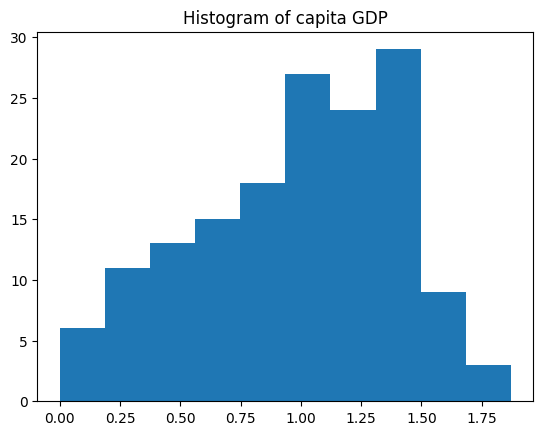

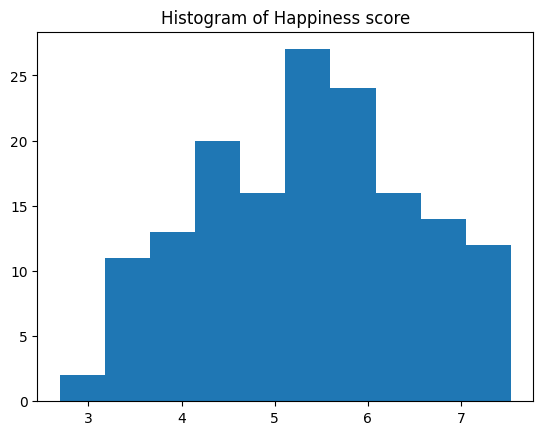

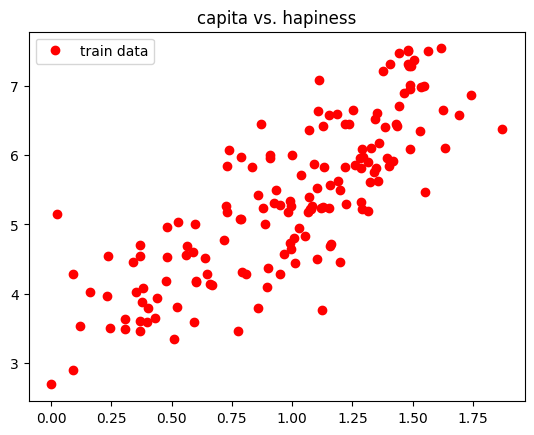

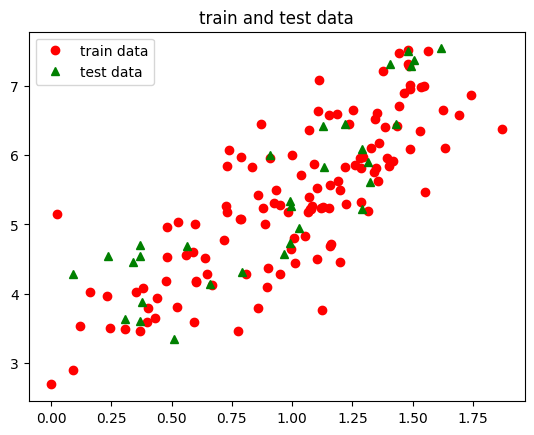

the learnt model: f(x) =  3.199548185216422  +  2.1489553125335217  * x


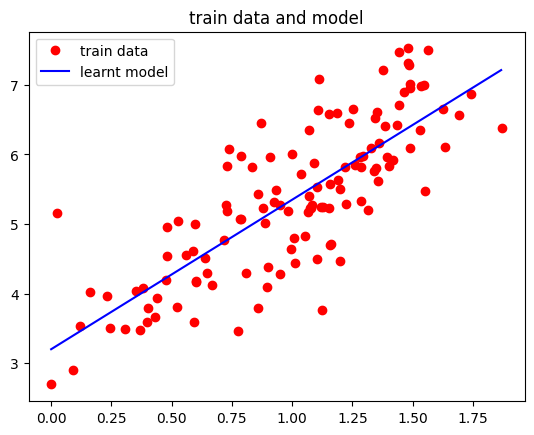

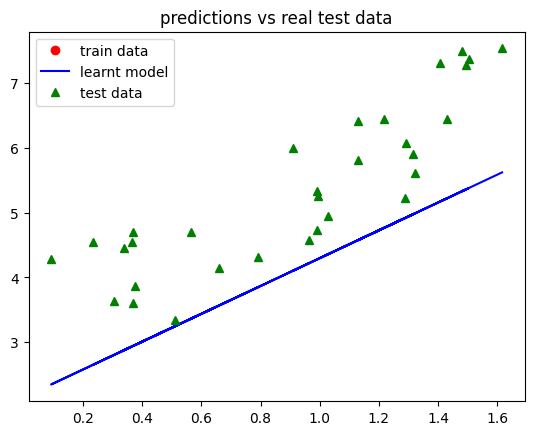

prediction error (manual):  1.8999752100241594
prediction error (tool):  1.8999752100241594

Pb1b: Bivariate Gradient Descent


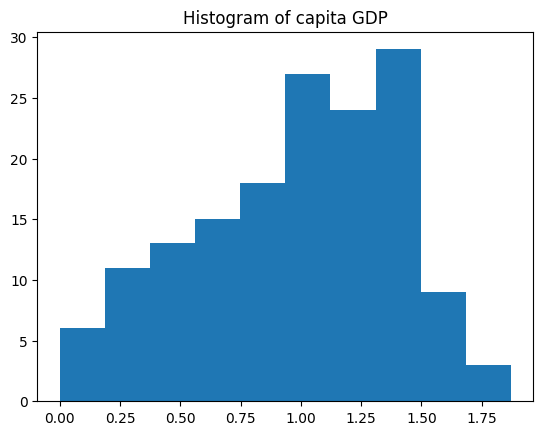

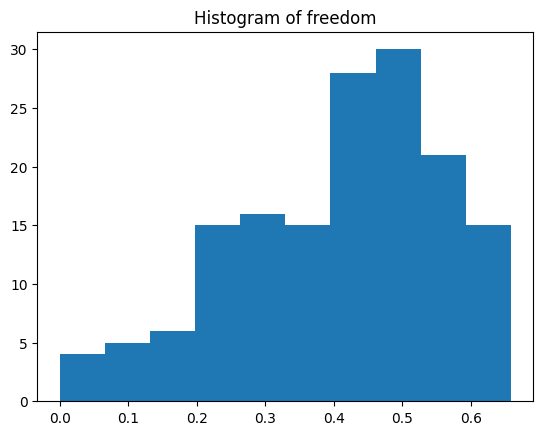

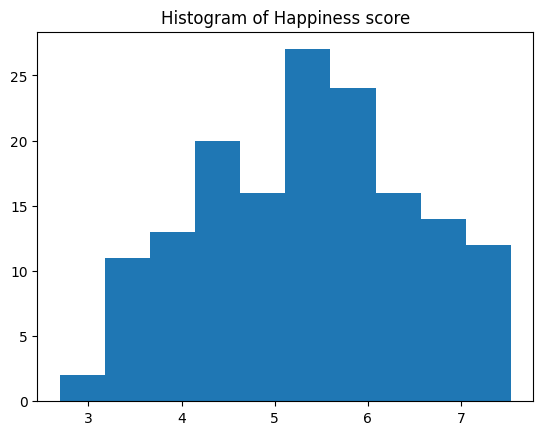

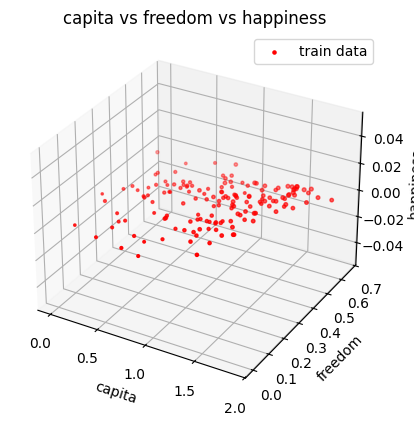

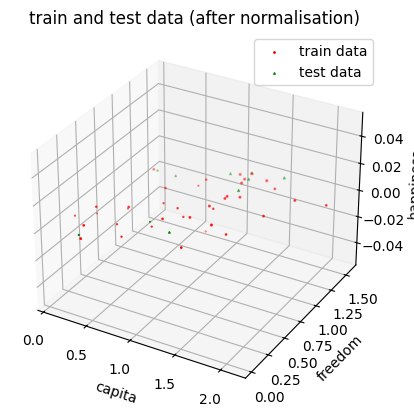

the learnt model: f(x) =  -0.0011659051562902811  +  0.6979590980445686  * x1 +  0.3039745892925814  * x2


/Users/alexandrabontidean/PycharmProjects/ai7/.venv/lib/python3.12/site-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


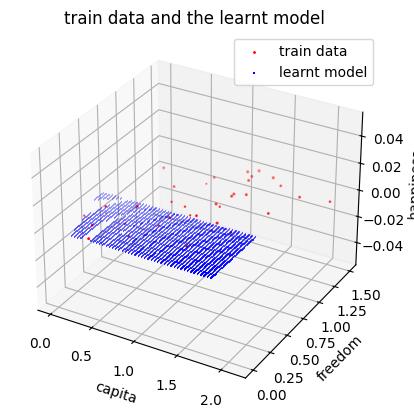

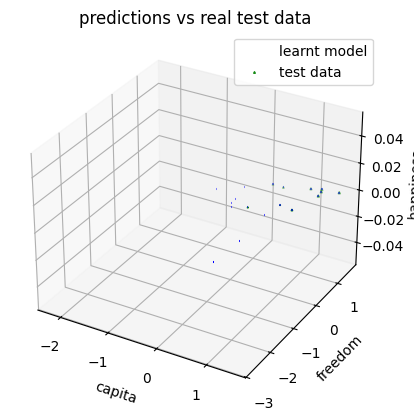

prediction error (manual):  0.23322521427524043
prediction error (tool):    0.2332252142752404

Pb2: Clasificarea tesuturilor cancerigene
Loss at iteration 0: 0.6912504218856401 (Binary Cross-Entropy Loss)
Loss at iteration 0 with threshold 0.2: 0.643956043956044 (Hinge Loss)
Loss at iteration 0 with threshold 0.2: 0.643956043956044 (Mean Squared Error)
Loss at iteration 0: 0.6912504218856401 (Binary Cross-Entropy Loss)
Loss at iteration 0 with threshold 0.5: 0.7626373626373626 (Hinge Loss)
Loss at iteration 0 with threshold 0.5: 0.10329670329670329 (Mean Squared Error)
Loss at iteration 0: 0.6912504218856401 (Binary Cross-Entropy Loss)
Loss at iteration 0 with threshold 0.9: 1.3560439560439561 (Hinge Loss)
Loss at iteration 0 with threshold 0.9: 0.35604395604395606 (Mean Squared Error)

Loss at iteration 10000: 0.21488517205151525 (Binary Cross-Entropy Loss)
Loss at iteration 10000 with threshold 0.2: 0.6879120879120879 (Hinge Loss)
Loss at iteration 10000 with threshold 0.2: 0.131868

/var/folders/v6/rk4pjc_90sdb8sg619l1jmc00000gn/T/ipykernel_28227/2124797772.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-z))


Modelul invatat: f(x) =  5.9512355143168  +  0.4414618863781543  * x1 +  6.797843714006512  * x2
Acuratete:  0.4666666666666667
Precizie:  0.8376811594202899
Recall:  0.4666666666666667
Specia prezisa pentru floare este:  Iris-versicolor

Optional: Clasificarea tesuturilor cancerigene cu cross-validation
Acuratetea pentru fiecare diviziune:  [0.85964912 0.92982456 0.90350877 0.85964912 0.87610619]
Acuratetea medie:  0.8857475547275268
Modelul invatat: f(x) =  -0.6994318055050132  +  3.336421768653383  * x1 +  0.8767014817409343  * x2
Leziunea este prezisa ca fiind maligna.


/var/folders/v6/rk4pjc_90sdb8sg619l1jmc00000gn/T/ipykernel_28227/2124797772.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (1 + math.exp(-z))


In [49]:
    print("\nPb1a: Univariate Gradient Descent")
    univariate_gradient_descent("batches")
    # STOCASTIC:
    # the learnt model: f(x) =  3.1994285956915123  +  2.1487678365481915  * x
    # prediction error (manual):  1.9008773201208433
    # prediction error (tool):  1.9008773201208433

    # BATCHES:
    # the learnt model: f(x) =  3.199548185216422  +  2.1489553125335217  * x
    # prediction error (manual):  1.8999752100241594
    # prediction error (tool):  1.8999752100241594

    print("\nPb1b: Bivariate Gradient Descent")
    bivariate_gradient_descent("batches")
    # STOCASTIC:
    # the learnt model: f(x) =  -0.0014527924544318889  +  0.6978631617347402  * x1 +  0.30375393537641193  * x2
    # prediction error (manual):  0.2331793993161317
    # prediction error (tool):    0.23317939931613166

    # BATCHES:
    # the learnt model: f(x) =  -0.0011659051562902811  +  0.6979590980445686  * x1 +  0.3039745892925814  * x2
    # prediction error (manual):  0.23322521427524043
    # prediction error (tool):    0.2332252142752404

    print("\nPb2: Clasificarea tesuturilor cancerigene")
    cancerous_tissues_classification("manual")
    # CU TOOL:
    # the learnt model: f(x) =  -0.9122440356107672  +  3.714265538441941  * x1 +  0.9215248354552286  * x2
    # Accuracy: 0.7982456140350878
    # The lesion is predicted to be malignant.

    # MANUAL:
    # the learnt model: f(x) =  -0.960872493582651  +  4.476084448566163  * x1 +  1.04464469245949  * x2
    # Accuracy: 0.8070175438596491
    # The lesion is predicted to be malignant.

    print("\nPb3: Ce fel de floare preferi?")
    flower_preference_classification("manual")
    # CU TOOL:
    # the learnt model: f(x) =  -0.10971986973912605  +  -0.9687222535134714  * x1 +  1.216084167441676  * x2
    # Accuracy:  0.9666666666666667
    # Precision:  0.9666666666666667
    # Recall:  0.9666666666666667
    # The predicted species for the flower is:  Iris-setosa

    # MANUAL:
    # the learnt model: f(x) =  3.491314967123042  +  3.1000205007035575  * x1 +  -1.0350808485476393  * x2
    # Accuracy:  0.5666666666666667
    # Precision:  0.415
    # Recall:  0.5666666666666667
    # The predicted species for the flower is:  Iris-setosa

    print("\nOptional: Clasificarea tesuturilor cancerigene cu cross-validation")
    cancerous_tissues_classification_cross_validation()
    # Accuracy:  0.887408787455364
    # the learnt model: f(x) =  -0.6994318055050132  +  3.336421768653383  * x1 +  0.8767014817409343  * x2
    # The lesion is predicted to be malignant.

In [50]:
import csv
import os

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Functie pentru a incarca datele din fisierul CSV
def loadDataMoreInputs3(fileName, inputVariabNames, outputVariabName, label_encoder):
    data = []
    dataNames = []
    with open(fileName) as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        line_count = 0
        for row in csv_reader:
            if line_count == 0:
                dataNames = row  # Incarcam denumirile coloanelor
            else:
                data.append(row)  # Incarcam datele
            line_count += 1
    selectedVariables = [dataNames.index(var) for var in inputVariabNames]  # Gasim indexurile variabilelor de intrare
    inputs = [[float(data[i][var]) for var in selectedVariables] for i in range(len(data))]  # Extragem datele de intrare
    selectedOutput = dataNames.index(outputVariabName)  # Gasim indexul variabilei de iesire
    outputs = [data[i][selectedOutput] for i in range(len(data))]  # Extragem iesirile

    # Codificam iesirile folosind LabelEncoder
    outputs_encoded = label_encoder.fit_transform(outputs)
    outputs_encoded = outputs_encoded.reshape(-1, 1)  # Redimensionam iesirile codificate

    return inputs, outputs_encoded

# Functie principala pentru clasificarea preferintelor de flori
def flower_preference_classification(modelType):
    crtDir = os.getcwd()  # Obtinem directorul curent
    filePath = os.path.join(crtDir, 'data', 'iris.csv')  # Calea catre fisierul CSV

    # Incarcam datele
    label_encoder = LabelEncoder()  # Creem un LabelEncoder pentru a codifica iesirile
    inputs, outputs = loadDataMoreInputs3(filePath, ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth'], 'Class', label_encoder)

    # PASUL 2: Imparte datele in seturi de antrenare (80%) si testare (20%) si normalizeaza datele
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]  # Cream un index pentru fiecare date
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)  # Alegem un subset aleator de date pentru antrenare
    testSample = [i for i in indexes if not i in trainSample]  # Restul sunt pentru testare

    # Separarea datelor de intrare si iesire pentru antrenare si testare
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    # Normalizarea datelor
    scaler = StandardScaler()
    scaler.fit(trainInputs)  # Calculam media si deviatiile standard pe datele de antrenament
    trainInputs = scaler.transform(trainInputs)  # Normalizam datele de antrenament
    testInputs = scaler.transform(testInputs)  # Normalizam datele de testare

    # PASUL 3: Antrenarea modelului
    if modelType == "tool":
        model = LogisticRegression()  # Cream un model de regresie logistica din biblioteca scikit-learn
        model.fit(trainInputs, np.ravel(trainOutputs))  # Antrenam modelul
        w0, w1 = model.intercept_, model.coef_[0]  # Obtinem coeficientii modelului
        print('Modelul invatat: f(x) = ', w0[0], ' + ', w1[0], ' * x1 + ', w1[1], ' * x2')
    else:
        # Implementarea unui model personalizat de regresie logistica
        model = MyLogisticRegression2(learning_rate=0.01, num_iterations=1000, threshold=0.33)
        model.fit(trainInputs, trainOutputs)  # Antrenam modelul personalizat
        learned_coefficients = model.theta  # Coeficientii invatati ai modelului
        print('Modelul invatat: f(x) = ', learned_coefficients[0][0], ' + ', learned_coefficients[1][0], ' * x1 + ',
              learned_coefficients[2][0], ' * x2')

    # PASUL 4: Calcularea performantelor modelului pe setul de testare
    computedTestOutputs = model.predict(testInputs)  # Facem predictii pe datele de testare

    # Afisam scorurile de acuratete, precizie si recall
    print('Acuratete: ', accuracy_score(np.ravel(testOutputs), computedTestOutputs))
    print('Precizie: ', precision_score(np.ravel(testOutputs), computedTestOutputs, average='weighted', zero_division=1))
    print('Recall: ', recall_score(np.ravel(testOutputs), computedTestOutputs, average='weighted', zero_division=1))

    # PASUL 5: Verificarea unui nou input
    normalized_inputs = scaler.transform([[5.35, 3.85, 1.25, 0.4]])  # Normalizam datele pentru un nou input
    prediction = model.predict(np.array(normalized_inputs))  # Facem predictia
    predicted_species = label_encoder.inverse_transform(prediction)  # Decodificam iesirea la numele speciei
    print("Specia prezisa pentru floare este: ", predicted_species[0])  # Afisam specia prezisa
